In [28]:
import pandas as pd
pumpkins = pd.read_csv('../data/US-pumpkins.csv')
pumpkins.tail()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
1752,ST. LOUIS,NaN,22 lb cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,14.75,14.75,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1753,ST. LOUIS,NaN,36 inch bins,MINIATURE,ROUND TYPE,NaN,9/26/16,275.00,275.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1754,ST. LOUIS,NaN,36 inch bins,MINIATURE,ROUND TYPE,NaN,9/27/16,275.00,275.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,STEADY.
1755,ST. LOUIS,NaN,36 inch bins,MINIATURE,ROUND TYPE,NaN,9/28/16,275.00,275.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,ABOUT STEADY.
1756,ST. LOUIS,NaN,36 inch bins,MINIATURE,ROUND TYPE,NaN,9/29/16,275.00,275.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,"MINIATURE LOWER, OTHERS STEADY."


In [29]:
import seaborn as sns

In [ ]:
# Filter the data to only include rows where the 'Package' column contains 'bushel'
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]

In [15]:
pumpkins.isnull().sum()

Package       0
Low Price     0
High Price    0
Date          0
dtype: int64

In [16]:
# Select the columns we want to keep
columns_to_select = ['Package', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]

In [17]:
# Find the average price of the pumpkins
price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

month = pd.DatetimeIndex(pumpkins['Date']).month

In [19]:
new_pumpkins = pd.DataFrame({'Month': month, 'Package': pumpkins['Package'], 'Low Price': pumpkins['Low Price'],'High Price': pumpkins['High Price'], 'Avg Price': price})
new_pumpkins.head()

,Month,Package,Low Price,High Price,Avg Price
70,9,1 1/9 bushel cartons,15.0,15.0,15.0
71,9,1 1/9 bushel cartons,18.0,18.0,18.0
72,10,1 1/9 bushel cartons,18.0,18.0,18.0
73,10,1 1/9 bushel cartons,17.0,17.0,17.0
74,10,1 1/9 bushel cartons,15.0,15.0,15.0


### Observation

Some of the pumpkins are sold in different configurations, if we look at the data closely we can see that some are sold in 1 1/9 bushel and others 1/2 bushel. The packages for the pumpkins are also unorganized and contain different measurements; some per pumpkin, per pound, and some in boxes with different widths.

In [20]:
# Normalize the price based on the package size
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/(1 + 1/9)

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price/(1/2)

In [21]:
import matplotlib.pyplot as plt

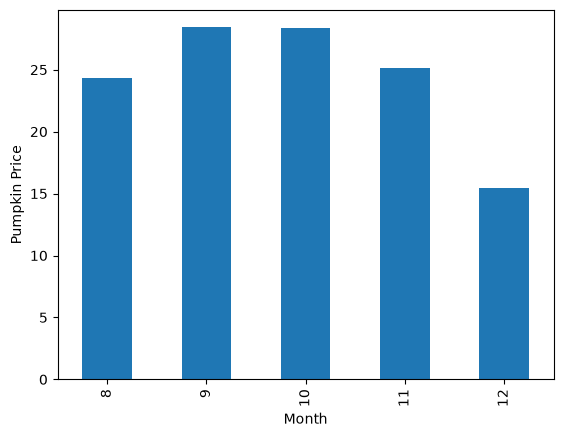

In [26]:
price = new_pumpkins.Price
month = new_pumpkins.Month

plt.bar(price, month)
new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')
plt.ylabel("Pumpkin Price")
plt.show()

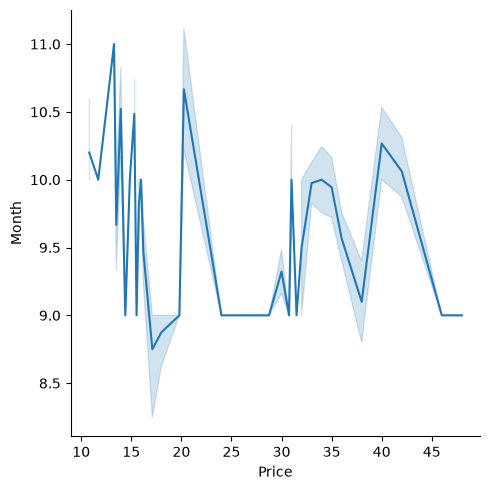

In [31]:
sns.relplot(x="Price", y="Month", kind="line" ,data=new_pumpkins)

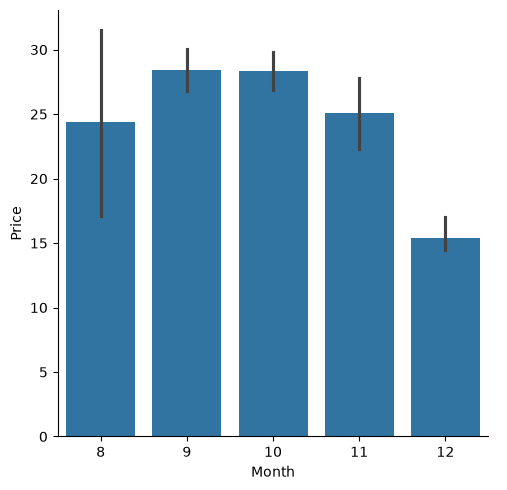

In [32]:
sns.catplot(x="Month", y="Price", data=new_pumpkins, kind="bar")

### Confidence Intervals

The black lines on the bar chart shows us how much pumpkin prices fluctuate during that month, we call this a confidence interval.

<Axes: >

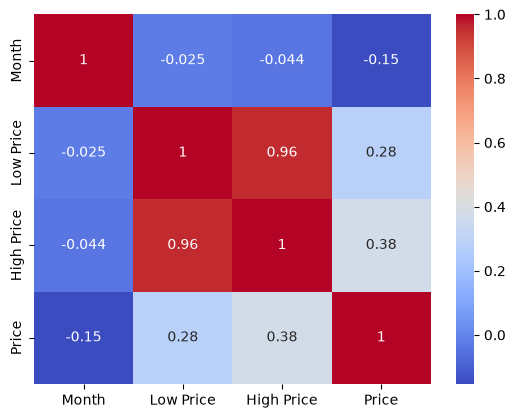

In [33]:
correlations = new_pumpkins[['Month', 'Low Price', 'High Price', 'Price']].corr()
sns.heatmap(correlations, annot=True, cmap="coolwarm")

### Heatmap

Heatmaps are a correlation matrix, which measures the strength and direction of linear relationships between pairs of values on a scale.

- 1.0: Perfect positive correlation, one variable moves as much as the other.
- 0.0: No linear relationship.
- -1.0: Perfect negative correlation, as one variable goes up the other one goes down.